In [151]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy import stats
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest, proportion_confint, proportion_effectsize
from statsmodels.stats.power import TTestIndPower, NormalIndPower
from statsmodels.stats.diagnostic import het_breuschpagan

In [152]:
df = pd.read_csv("TXC_25_landingpage.csv")
print(df['arm'].value_counts())

df

arm
control      1308
treatment    1301
pre          1088
Name: count, dtype: int64


,group_id,arm,visitor_id,arrival_time,exit_time,time_on_page_sec,exit_rate,ctr_opportunities,ctr_newsletter,ctr_donation,ctr_events,kpi_x,kpi_y,scroll_depth_pct,ctr_partner_banner,page_load_time_ms
0,TXC_25,treatment,2497,2026-02-22 12:41:07,2026-02-22 12:45:05.9,238.9,0,0,0,0,0,23.380,0,95.50,0,7105.8
1,TXC_25,control,2258,2026-02-22 13:00:26,2026-02-22 13:01:10,44.0,0,0,0,0,0,0.642,0,2.16,0,1719.3
2,TXC_25,control,1474,2026-02-22 13:47:04,2026-02-22 13:50:53.8,229.8,0,1,0,0,0,20.892,0,36.72,0,6193.4
3,TXC_25,treatment,2708,2026-02-22 15:01:01,2026-02-22 15:01:05.2,4.2,1,0,0,0,0,0.360,0,8.20,0,2293.9
4,TXC_25,pre,477,2026-02-22 15:15:46,2026-02-22 15:16:40.9,54.9,0,0,0,0,0,96.350,0,16.90,0,1779.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3692,TXC_25,pre,970,2026-03-06 15:12:46,2026-03-06 15:13:26.1,40.1,0,0,0,0,0,75.660,0,5.90,1,4193.2
3693,TXC_25,pre,181,2026-03-06 15:17:21,2026-03-06 15:18:02.6,41.6,0,0,0,0,0,38.370,0,4.00,0,1504.6
3694,TXC_25,control,1801,2026-03-06 15:38:44,2026-03-06 15:38:57.8,13.8,0,0,0,0,1,49.824,0,57.66,0,1469.3
3695,TXC_25,pre,374,2026-03-06 16:42:18,2026-03-06 16:42:18.9,0.9,1,0,0,0,0,3.310,0,7.90,0,1466.9


In [153]:
# Data cleaning
df_pre   = df[df['arm'] == 'pre_period'].copy()
df_exp   = df[df['arm'].isin(['control', 'treatment'])].copy()

ctr_donate = df_exp["ctr_donation"]
dwell_time = df_exp["time_on_page_sec"]

# Check for exact duplicates
n_dupes = df_exp.duplicated().sum()
print(f'Exact duplicate rows: {n_dupes}')

# drop unused columns
df_exp = df_exp.drop(columns=["visitor_id", "group_id", 'kpi_x', 'kpi_y', 'exit_time', 'ctr_events', 'ctr_newsletter', 'ctr_opportunities', 'ctr_partner_banner', 'exit_rate'])

# negative or zero dwell time
mask_neg = dwell_time <= 0
print(f'Rows with dwell ≤ 0: {mask_neg.sum()}')

# non binary ctr-donation entries
non_binary_count = (~ctr_donate.isin([0, 1])).sum()
print(f"CTR donation non-binary: {non_binary_count}")

# negative or zero page load time
bad_load = df_exp['page_load_time_ms'] <= 0
print(f"Rows with negative or zero page_load_time: {bad_load.sum()}")

# negative scroll depth percentage
bad_scroll = df_exp['scroll_depth_pct'] < 0
print(f"Rows with negative scroll depth percentage: {bad_scroll.sum()}")

# guarantee arrival time is datetime object
df_exp['arrival_time'] = pd.to_datetime(df_exp['arrival_time'], errors='coerce')

df_exp

Exact duplicate rows: 0
Rows with dwell ≤ 0: 0
CTR donation non-binary: 0
Rows with negative or zero page_load_time: 0
Rows with negative scroll depth percentage: 0


,arm,arrival_time,time_on_page_sec,ctr_donation,scroll_depth_pct,page_load_time_ms
0,treatment,2026-02-22 12:41:07,238.9,0,95.50,7105.8
1,control,2026-02-22 13:00:26,44.0,0,2.16,1719.3
2,control,2026-02-22 13:47:04,229.8,0,36.72,6193.4
3,treatment,2026-02-22 15:01:01,4.2,0,8.20,2293.9
5,treatment,2026-02-22 15:57:59,48.5,0,100.00,910.2
...,...,...,...,...,...,...
3687,treatment,2026-03-06 10:17:12,15.3,0,83.50,1822.6
3690,control,2026-03-06 14:35:31,192.9,0,1.70,1611.7
3691,treatment,2026-03-06 15:00:18,17.0,0,18.80,1815.8
3694,control,2026-03-06 15:38:44,13.8,0,57.66,1469.3


In [154]:
# Outlier analysis
# checking for dwell time extreme outliers
q1 = df_exp['time_on_page_sec'].quantile(0.25)
q3 = df_exp['time_on_page_sec'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 3 * iqr

print(f'IQR = {iqr:.1f} sec')
print(f'Upper Tukey fence (3 x IQR): {upper_fence:.1f} sec')

# Add time out limit (30 minutes is regarded as open tab or similar)
CAP_SECONDS = 1800

# create outlier flags
df_exp['outlier_tukey'] = dwell_time > upper_fence
df_exp['outlier_cap'] = dwell_time > CAP_SECONDS

print(f'Outliers above Tukey fence: {df_exp["outlier_tukey"].sum()}')
print(f'Outliers above 30 min cap: {df_exp["outlier_cap"].sum()}')

# winsorize dwell time for main analysis
p99 = df_exp['time_on_page_sec'].quantile(0.99)
print(f'99th percentile cap: {p99:.1f} sec')
df_exp['dwell_wins'] = dwell_time.clip(upper=p99)

# log transform dwell time
df_exp['dwell_log'] = np.log1p(dwell_time)

# balance check
print('\nOutlier balance by arm:')
print(df_exp.groupby('arm')['outlier_tukey'].sum())

IQR = 147.8 sec
Upper Tukey fence (3 x IQR): 602.1 sec
Outliers above Tukey fence: 179
Outliers above 30 min cap: 117
99th percentile cap: 6071.3 sec

Outlier balance by arm:
arm
control      88
treatment    91
Name: outlier_tukey, dtype: int64


In [155]:
# Sample Ratio Mismatch test: are the two arms equal-sized as designed?
arm_counts = df_exp['arm'].value_counts()
expected = np.array([len(df_exp) / 2, len(df_exp) / 2])
observed = arm_counts[['control', 'treatment']].values
chi2_srm, p_srm = stats.chisquare(observed, expected)
print(f'SRM chi-square = {chi2_srm:.4f}, p = {p_srm:.4f}')

SRM chi-square = 0.0188, p = 0.8910


In [156]:
# covariate balance of guardrails between arms
covariates = ['scroll_depth_pct', 'page_load_time_ms']
balance = df_exp.groupby('arm')[covariates].mean().T
print('Mean covariate values by arm:')
print(balance.round(2))

# t-tests for balance
print('\nBalance t-tests (control vs treatment):')
ctrl = df_exp[df_exp['arm'] == 'control']
trt  = df_exp[df_exp['arm'] == 'treatment']
for cov in covariates:
    t, p = ttest_ind(ctrl[cov], trt[cov])
    print(f'  {cov:25s}  t={t:6.3f}  p={p:.3f}')

Mean covariate values by arm:
arm                control  treatment
scroll_depth_pct     22.35      41.71
page_load_time_ms  2036.87    2123.81

Balance t-tests (control vs treatment):
  scroll_depth_pct           t=-17.634  p=0.000
  page_load_time_ms          t=-1.108  p=0.268


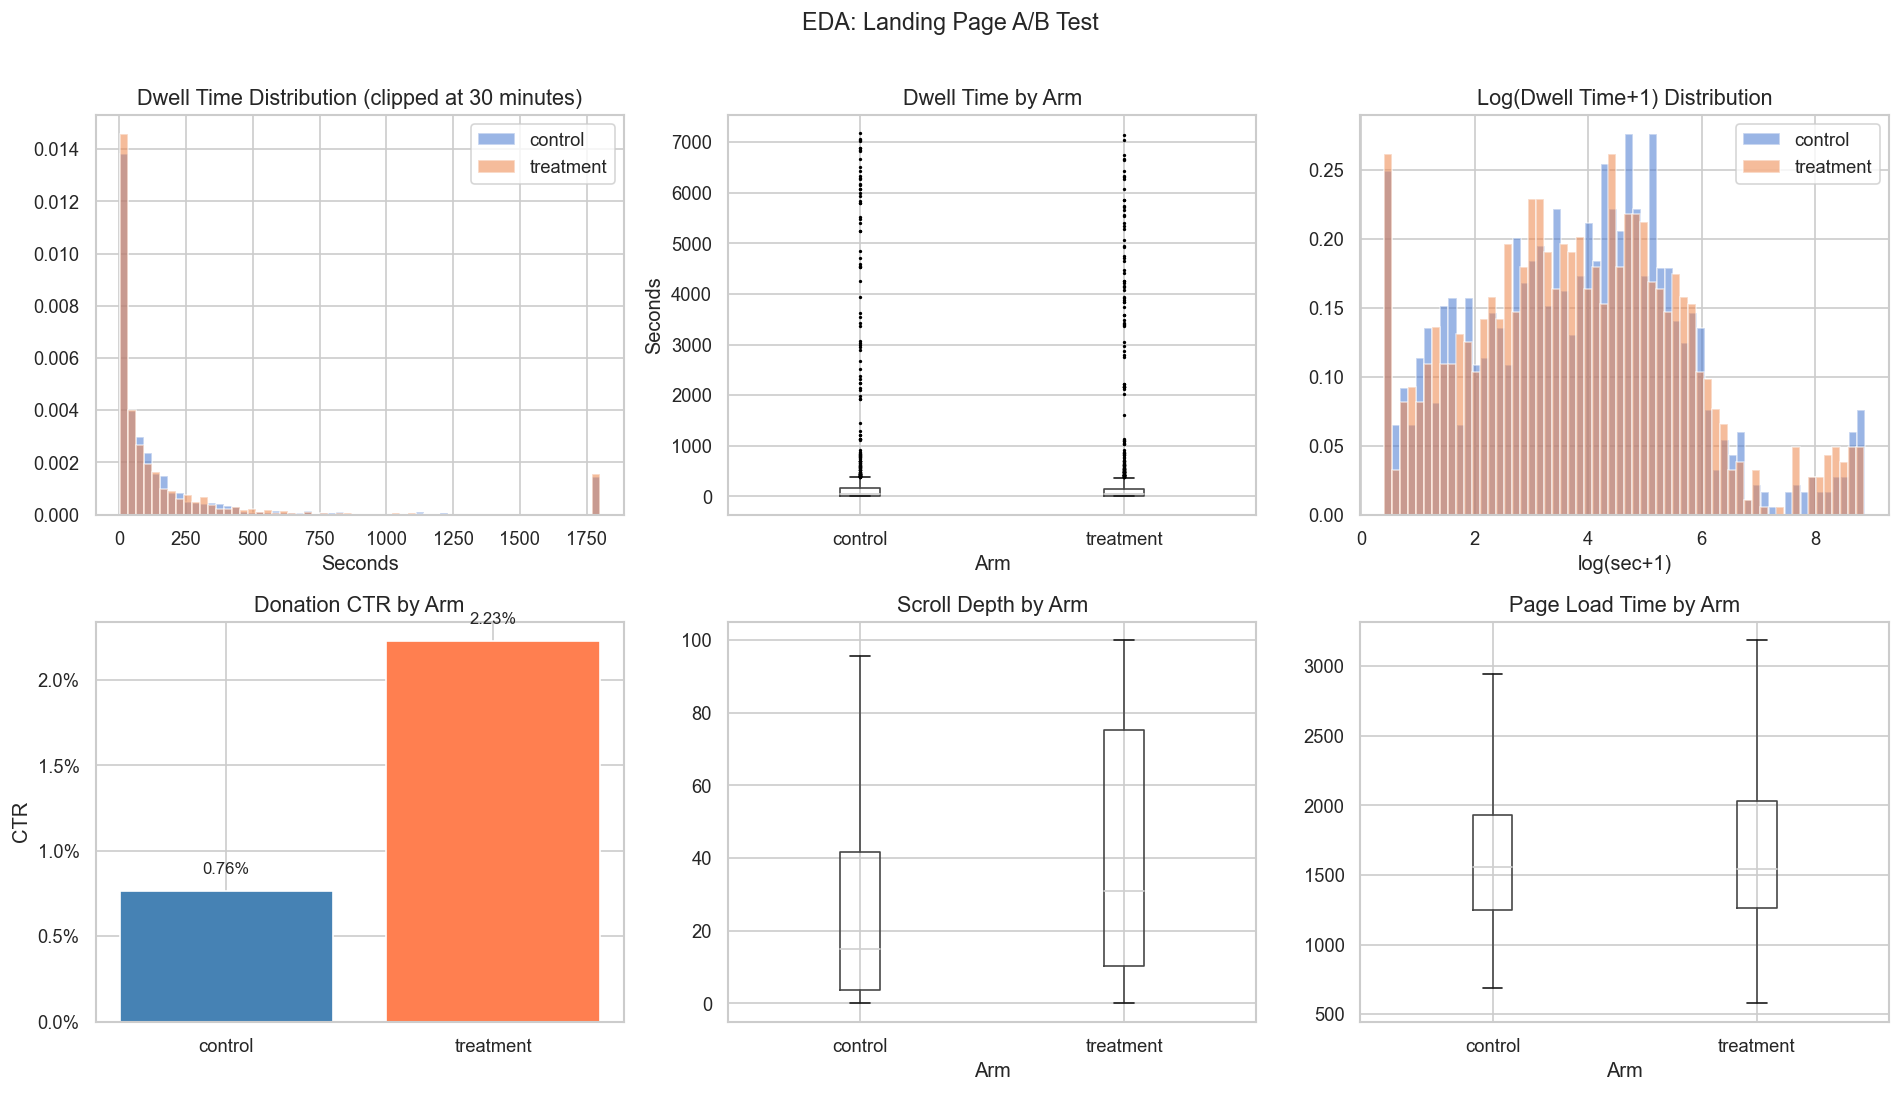

In [157]:
# Visualizations
# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Dwell time distributions
for arm, grp in df_exp.groupby('arm'):
    axes[0,0].hist(grp['time_on_page_sec'].clip(upper=1800), bins=60,
                   alpha=0.55, label=arm, density=True)
axes[0,0].set_title('Dwell Time Distribution (clipped at 30 minutes)')
axes[0,0].set_xlabel('Seconds')
axes[0,0].legend()

# Box plots dwell time
df_exp.boxplot(column='time_on_page_sec', by='arm', ax=axes[0,1],
               showfliers=True, flierprops=dict(marker='.', markersize=2))
axes[0,1].set_title('Dwell Time by Arm')
axes[0,1].set_xlabel('Arm')
axes[0,1].set_ylabel('Seconds')
plt.sca(axes[0,1]); plt.title('Dwell Time by Arm')

# Log dwell time
for arm, grp in df_exp.groupby('arm'):
    axes[0,2].hist(grp['dwell_log'], bins=60, alpha=0.55, label=arm, density=True)
axes[0,2].set_title('Log(Dwell Time+1) Distribution')
axes[0,2].set_xlabel('log(sec+1)')
axes[0,2].legend()

# CTR bar chart
ctr_by_arm = df_exp.groupby('arm')['ctr_donation'].mean().reset_index()
axes[1,0].bar(ctr_by_arm['arm'], ctr_by_arm['ctr_donation'], color=['steelblue','coral'])
axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
axes[1,0].set_title('Donation CTR by Arm')
axes[1,0].set_ylabel('CTR')
for i, row in ctr_by_arm.iterrows():
    axes[1,0].text(i, row['ctr_donation'] + 0.001, f"{row['ctr_donation']:.2%}",
                   ha='center', fontsize=10)

# Scroll depth by arm
df_exp.boxplot(column='scroll_depth_pct', by='arm', ax=axes[1,1],
               showfliers=False)
axes[1,1].set_title('Scroll Depth by Arm')
axes[1,1].set_xlabel('Arm')
plt.sca(axes[1,1]); plt.title('Scroll Depth by Arm')

# Page load time by arm
df_exp.boxplot(column='page_load_time_ms', by='arm', ax=axes[1,2],
               showfliers=False)
axes[1,2].set_title('Page Load Time by Arm')
axes[1,2].set_xlabel('Arm')
plt.sca(axes[1,2]); plt.title('Page Load Time by Arm')

fig.suptitle('EDA: Landing Page A/B Test', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [158]:
# error pattern diagnostic
# Very short sessions (less than 1 second) tend to be bots or similar
n_bots = (dwell_time < 1).sum()
pct_bots = n_bots / len(df_exp) * 100
print(f'Sessions < 1 sec:  {n_bots}  ({pct_bots:.1f}%)')
bots_by_arm = df_exp[dwell_time < 1]['arm'].value_counts()
print(bots_by_arm)

# Page load time outliers could influence dwell time
p95_load = df_exp['page_load_time_ms'].quantile(0.95)
n_slow_load = (df_exp['page_load_time_ms'] > p95_load).sum()
print(f'\nSessions with high page load ( > 95th pct: {p95_load:.0f} ms):  {n_slow_load}')
slow_load_by_arm = df_exp[df_exp['page_load_time_ms'] > p95_load]['arm'].value_counts()
print(slow_load_by_arm)

# Temporal balance — were arms exposed at the same times?
df_exp['hour_of_day'] = df_exp['arrival_time'].dt.hour
hour_balance = df_exp.groupby(['arm', 'hour_of_day']).size().unstack(fill_value=0)
print('\nHourly traffic balance:')
print(hour_balance.T)

Sessions < 1 sec:  112  (4.3%)
arm
control      58
treatment    54
Name: count, dtype: int64

Sessions with high page load ( > 95th pct: 5374 ms):  131
arm
treatment    74
control      57
Name: count, dtype: int64

Hourly traffic balance:
arm          control  treatment
hour_of_day                    
0.0                2          2
1.0                1          0
2.0                0          1
4.0                2          2
7.0                0          1
8.0                1          0
9.0                0          2
10.0               0          1
12.0               0          1
13.0               2          0
14.0               1          0
15.0               1          3
16.0               3          2
17.0               0          1
18.0               1          0
20.0               2          1
22.0               0          1
23.0               0          1


In [159]:
# Power calculation — CTR
# parameters based on pre-period baseline
baseline_ctr = df_pre['ctr_donation'].mean()
print(f'Pre-period baseline donation CTR: {baseline_ctr:.4f}')

# Minimum detectable effect (MDE): assume we care about a 1 pp lift
mde_ctr = 0.01
baseline = baseline_ctr
p0 = baseline_ctr
p1 = p0 + mde_ctr

alpha = 0.05
power_target = 0.80

# Two-proportion z-test sample size
effect_size_ctr = proportion_effectsize(p1, p0)
analysis_ctr = NormalIndPower()
n_required_ctr = analysis_ctr.solve_power(effect_size=effect_size_ctr,
                                             alpha=alpha,
                                             power=power_target,
                                             alternative='two-sided')
print(f'\nCTR Power Calculation')
print(f'Baseline CTR (p0) = {p0:.4f}')
print(f'Target CTR (p1) = {p1:.4f}')
print(f'MDE = {mde_ctr:.3f} ({mde_ctr/p0*100:.0f}% relative)')
print(f'Effect size (Cohen h) = {effect_size_ctr:.4f}')
print(f'Required N per arm = {int(np.ceil(n_required_ctr))}')
print(f'Actual N per arm ≈ {len(ctrl):,}')
actual_power_ctr = analysis_ctr.solve_power(effect_size=effect_size_ctr,
                                              alpha=alpha,
                                              nobs1=len(ctrl),
                                              alternative='two-sided')
print(f'Achieved power (at actual N) = {actual_power_ctr:.3f}')

Pre-period baseline donation CTR: nan

CTR Power Calculation
Baseline CTR (p0) = nan
Target CTR (p1) = nan
MDE = 0.010 (nan% relative)
Effect size (Cohen h) = nan
Required N per arm = 10
Actual N per arm ≈ 1,308
Achieved power (at actual N) = nan


/Users/korbiniandietl/anaconda3/lib/python3.11/site-packages/statsmodels/stats/power.py:525: ConvergenceWarning: 
Failed to converge on a solution.

  warnings.warn(convergence_doc, ConvergenceWarning)
